In [12]:
from typing import TypedDict ,Annotated,operator
from langgraph.graph import StateGraph , START , END
from langchain_huggingface import  ChatHuggingFace,HuggingFaceEndpoint


In [13]:
import dotenv
dotenv.load_dotenv()
import os

In [14]:
HUGGINGFACEHUB_API_TOKEN = os.getenv('HUGGINGFACEHUB_API_TOKEN')

In [15]:
llm = HuggingFaceEndpoint(
    repo_id='meta-llama/Llama-3.1-8B-Instruct',
    task='text-generation',
    huggingfacehub_api_token= HUGGINGFACEHUB_API_TOKEN
)

In [16]:
model = ChatHuggingFace(llm = llm)

In [17]:
class State(TypedDict):
    question:str
    analysis:Annotated[list[str],operator.add] # add as reducer function
    summary : str

In [18]:
def technical_analysis(state:State):
    question = state['question']

    prompt =  f"""
        Analyze this question from a technical perspective.

        Question:
        {question}
        """
    
    analysis = model.invoke(prompt).content
    return {'analysis':[analysis]}

def business_analysis(state:State):
    question = state['question']

    prompt =  f"""
        Analyze this question from a business perspective.

        Question:
        {question}
        """
    
    analysis = model.invoke(prompt).content
    return {'analysis':[analysis]}


def risk_analysis(state:State):
    question = state['question']

    prompt =  f"""
         Analyze potential risks related to this question.

        Question:
        {question}
        """
    
    analysis = model.invoke(prompt).content
    return {'analysis':[analysis]}



In [19]:
def summary(state:State):

    prompt =  f"""
        You are a senior decision-maker.

        Combine the following analyses into a
        single coherent answer.

        {state['analysis']}
        """
    
    state['summary']=model.invoke(prompt).content
    
    return state

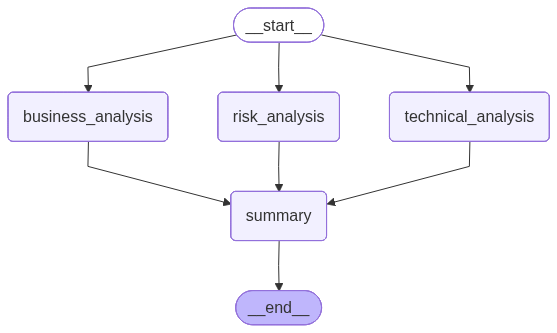

In [20]:
graph = StateGraph(State)

graph.add_node('technical_analysis' , technical_analysis)
graph.add_node('business_analysis',business_analysis)
graph.add_node('risk_analysis',risk_analysis)

graph.add_node('summary',summary)

graph.add_edge(START,'technical_analysis')
graph.add_edge(START,'business_analysis')
graph.add_edge(START,'risk_analysis')

graph.add_edge('technical_analysis','summary')
graph.add_edge('business_analysis','summary')
graph.add_edge('risk_analysis','summary')

graph.add_edge('summary',END)

workflow = graph.compile()

workflow

In [21]:
inital_state = {'question':'Our application experiences intermittent latency spikes during peak traffic. What is the most likely root cause and how should we investigate it?'}

final_state = workflow.invoke(inital_state)

print(final_state['summary'])

### **Comprehensive Analysis of Intermittent Latency Spikes During Peak Traffic**

#### **Business Impact of Latency Spikes**
Intermittent latency spikes during peak traffic can severely impact business outcomes, including:
- **Customer Experience (CX):** High latency leads to frustration, cart abandonment, and reduced engagement, directly affecting revenue.
- **Reputation Risk:** Poor performance damages brand credibility, particularly in competitive industries (e.g., fintech, SaaS).
- **Operational Costs:** Increased support tickets, refunds, or SLA penalties (if applicable).
- **Competitive Disadvantage:** Users may switch to faster alternatives, especially in speed-sensitive markets (e.g., gaming, trading).

#### **Most Likely Root Causes (Business & Technical Perspectives)**
1. **Insufficient Scaling (Cost vs. Performance Trade-off)**
   - **Static Infrastructure:** Fixed server capacity may be overwhelmed during peak traffic.
   - **Auto-Scaling Delays:** Cloud resources may fail

In [22]:
print(final_state['analysis'])

['### **Business Perspective Analysis of the Question**\n\n#### **1. Business Impact of Latency Spikes**\n- **Customer Experience (CX):** High latency degrades user experience, leading to frustration, abandonment, and potential loss of revenue (e.g., e-commerce cart abandonment).\n- **Reputation Risk:** Poor performance can damage brand credibility, especially in competitive industries (e.g., fintech, SaaS).\n- **Operational Costs:** Increased support tickets, refunds, or SLA penalties (if applicable).\n- **Competitive Disadvantage:** Users may switch to faster alternatives, especially in markets where speed is critical (e.g., gaming, trading platforms).\n\n#### **2. Most Likely Root Causes (Business-Focused)**\nFrom a business perspective, the most probable causes of intermittent latency spikes during peak traffic are:\n\n1. **Insufficient Scaling (Cost vs. Performance Trade-off)**\n   - **Static Infrastructure:** If the application is not auto-scaling (e.g., fixed server capacity), p